# 02 · Module Scores → Principal Circle → Phase θ

**Purpose:** compute S-phase and G2/M module scores, fit a **principal circle** in that 2-D space, assign each cell a **cell-cycle phase** (θ ∈ [0, 2π)), and save diagnostics for downstream analysis.

### What this notebook does

* Loads `data/interim/mm_timecourse.h5ad` (built in **01**).
* Normalizes from `layers["counts"]` → library-size (1e4) + `log1p`.
* Computes **S** and **G2/M** module scores (per-gene z-score, then mean within set).
* Fits a least-squares **circle** in (S_score, G2M_score) space.
* Projects each cell onto the circle → **phase θ** and **radius**.
* Fixes orientation so **S** peaks near θ≈0 and **G2/M** is ~+π/2.
* Saves a figure of the ring with the fitted circle and phase coloring.

### Inputs (expected on disk)

* `data/interim/mm_timecourse.h5ad`
* Marker files:

  * `configs/markers/S_mouse.txt`
  * `configs/markers/G2M_mouse.txt`

### Outputs

* Updated `mm_timecourse.h5ad` with:

  * `obs["S_score"]`, `obs["G2M_score"]`
  * `obs["phase_theta"]` (radians in [0, 2π))
  * `obs["radius"]` (distance to circle center)
* Figure: `outputs/figures/fig01_s_vs_g2m_circle.png`

### Run order

1. Run **00_Preamble** (or ensure its logic is replicated here).
2. Run this notebook top-to-bottom.
3. Proceed to **03_mixture_cycling.ipynb** (annulus–disk mixture for cycling vs quiescent).

### Quick validation checklist

* Scatter of S vs G2/M shows a **ring-like** structure.
* Fitted circle overlays the ring sensibly (center near data centroid).
* High-S cells have θ near **0**; high-G2/M shifted by ~**+π/2**.
* θ looks smoothly varying on t-SNE/PHATE (optional check).

### Notes & assumptions

* We use a **simple circle** (not a closed principal curve) for robustness and speed.
* Gene z-scoring is done **across cells** on the normalized log matrix.
* If very few markers are found, check gene symbol casing and lists.


In [1]:
# --- Cell 1: setup, resolve paths, import helpers, load AnnData ---
from pathlib import Path
import sys, yaml
import numpy as np, pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt

# robust project root finder (walk up until configs/params.yaml is found)
def repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for _ in range(8):
        if (p / "configs" / "params.yaml").exists():
            return p
        p = p.parent
    raise FileNotFoundError("Open this notebook inside the project folder (configs/params.yaml not found).")

BASE = repo_root()
P = yaml.safe_load(open(BASE / "configs" / "params.yaml")) or {}
ANNDATA = BASE / P.get("paths", {}).get("anndata", "data/interim/mm_timecourse.h5ad")
FIGDIR  = BASE / P.get("paths", {}).get("figures", "outputs/figures")
FIGDIR.mkdir(parents=True, exist_ok=True)

# helper functions (circle fit, angles, orientation)
LIB = BASE / "notebooks" / "_lib"
if str(LIB) not in sys.path:
    sys.path.insert(0, str(LIB))
from cc_limitcycle import fit_circle, angles_from_center, orient_phases  # noqa: E402

# load object built in 01
adata = ad.read_h5ad(ANNDATA)
print("Loaded:", ANNDATA)
print("Shape  :", adata.n_obs, "cells ×", adata.n_vars, "genes")
print("obs cols (head):", list(adata.obs.columns)[:10])
print("obsm keys:", list(adata.obsm_keys()))


Loaded: /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/data/interim/mm_timecourse.h5ad
Shape  : 3891 cells × 52638 genes
obs cols (head): ['sampleID', 'CODING_BASES', 'INTERGENIC_BASES', 'INTRONIC_BASES', 'MEDIAN_3PRIME_BIAS', 'MEDIAN_5PRIME_BIAS', 'MEDIAN_5PRIME_TO_3PRIME_BIAS', 'MEDIAN_CV_COVERAGE', 'NUM_R1_TRANSCRIPT_STRAND_READS', 'NUM_R2_TRANSCRIPT_STRAND_READS']
obsm keys: ['X_phate', 'X_tsne']


In [2]:
# --- Cell 2: normalize from counts + load S/G2M marker lists ---
import scanpy as sc

# 2a) normalize X from raw counts layer
assert "counts" in adata.layers, "Missing adata.layers['counts'] from notebook 01."
adata.X = adata.layers["counts"].copy()
sc.pp.normalize_total(adata, target_sum=1e4, inplace=True)
sc.pp.log1p(adata)  # log1p CPM-like

# 2b) load marker files from config and intersect with genes
S_file   = BASE / P.get("markers", {}).get("s_file",  "configs/markers/S_mouse.txt")
G2M_file = BASE / P.get("markers", {}).get("g2m_file","configs/markers/G2M_mouse.txt")

def load_markers(path: Path) -> list[str]:
    assert path.exists(), f"Marker file not found: {path}"
    return [ln.strip() for ln in open(path) if ln.strip() and not ln.startswith("#")]

S_list  = load_markers(S_file)
G2M_list= load_markers(G2M_file)

present = set(adata.var_names)
S = sorted(present.intersection(S_list))
M = sorted(present.intersection(G2M_list))

# fallback: case-insensitive matching if too few hits
if len(S) < 8 or len(M) < 8:
    lower_map = {g.lower(): g for g in adata.var_names}
    S = sorted(lower_map[g.lower()] for g in S_list  if g.lower() in lower_map)
    M = sorted(lower_map[g.lower()] for g in G2M_list if g.lower() in lower_map)

# stash for reproducibility
adata.uns["markers"] = {"S": S, "G2M": M, "S_file": str(S_file), "G2M_file": str(G2M_file)}

print(f"Normalized X from counts. Genes in adata: {adata.n_vars}")
print(f"S markers found:   {len(S)} / {len(S_list)}  → sample: {S[:5]}")
print(f"G2/M markers found:{len(M)} / {len(G2M_list)} → sample: {M[:5]}")
assert len(S) >= 8 and len(M) >= 8, "Too few S/G2M markers found — check gene symbols or marker files."


Normalized X from counts. Genes in adata: 52638
S markers found:   41 / 41  → sample: ['Ccne2', 'Cdc45', 'Cdca7', 'Cenpu', 'Chtf18']
G2/M markers found:43 / 46 → sample: ['Anp32e', 'Aurka', 'Aurkb', 'Birc5', 'Bub1']


S markers used:   41  (example: ['Ccne2', 'Cdc45', 'Cdca7', 'Cenpu', 'Chtf18'])
G2/M markers used:43  (example: ['Anp32e', 'Aurka', 'Aurkb', 'Birc5', 'Bub1'])


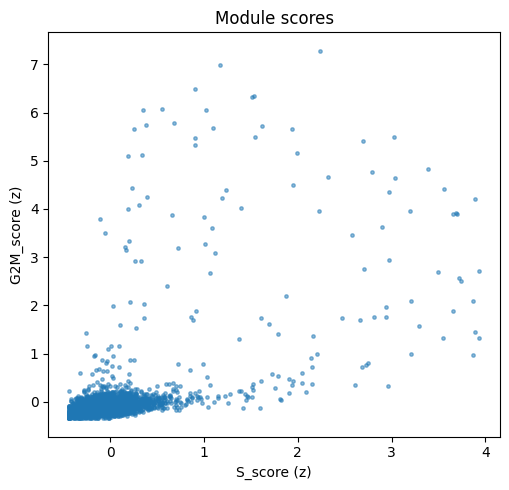

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/outputs/figures/fig00_module_scores_scatter.png


In [5]:
# --- Cell 3: compute S/G2M module scores (robust) ---
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse

def map_genes_present(genes, varnames):
    """Case-insensitive mapping of requested genes to adata.var_names."""
    present = set(varnames)
    ok = [g for g in genes if g in present]
    if len(ok) < 8:
        lower_map = {v.lower(): v for v in varnames}
        ok = [lower_map[g.lower()] for g in genes if g.lower() in lower_map]
    return ok

def to_2d_array(X):
    """Return a dense 2-D ndarray from AnnData .X slice."""
    if sparse.issparse(X):
        A = X.toarray()
    else:
        A = np.asarray(X)
    if A.ndim == 0:
        raise ValueError("Selection produced a 0-D array (no markers matched).")
    if A.ndim == 1:
        A = A.reshape(-1, 1)
    return A

def module_score_z(adata, gene_list):
    ok = map_genes_present(gene_list, adata.var_names)
    if len(ok) == 0:
        raise ValueError("No requested genes are present in adata.var_names.")
    X = to_2d_array(adata[:, ok].X)   # shape: n_cells × n_genes_used
    mu = X.mean(axis=0, dtype=np.float64)
    sd = X.std(axis=0, dtype=np.float64)
    sd[sd == 0] = 1.0
    Z = (X - mu) / sd
    return Z.mean(axis=1).ravel(), ok

S_score, S_used = module_score_z(adata, S)
M_score, M_used = module_score_z(adata, M)

adata.obs["S_score"]   = S_score
adata.obs["G2M_score"] = M_score
adata.uns["markers_used"] = {"S": S_used, "G2M": M_used}

print(f"S markers used:   {len(S_used)}  (example: {S_used[:5]})")
print(f"G2/M markers used:{len(M_used)}  (example: {M_used[:5]})")

# quick preview scatter
plt.figure(figsize=(5.2,5))
plt.scatter(adata.obs["S_score"], adata.obs["G2M_score"], s=6, alpha=0.5)
plt.xlabel("S_score (z)"); plt.ylabel("G2M_score (z)"); plt.title("Module scores")
plt.tight_layout()
out = FIGDIR / "fig00_module_scores_scatter.png"
plt.savefig(out, dpi=200, bbox_inches="tight"); plt.show()
print("[saved]", out)


Markers used → S: 41 | G2/M: 43
Pearson r (top 30% cycling-ish) = 0.53  (expect negative, e.g. -0.5±0.3)
High-S only: 50 | High-G2/M only: 65 | High-both (rare): 180


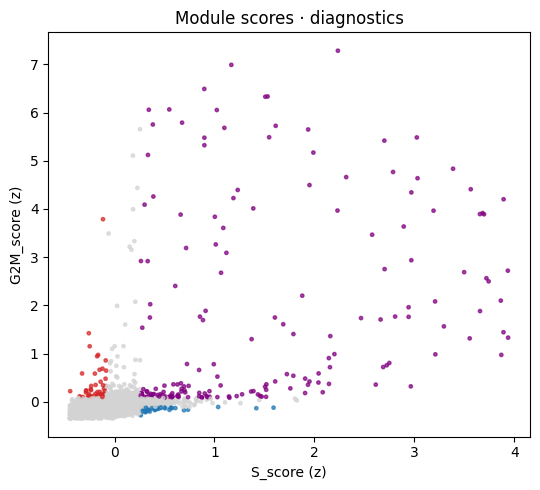

In [6]:
# --- Diagnostics: are S and G2/M behaving like cell-cycle modules? ---
import numpy as np
import matplotlib.pyplot as plt

S_score = adata.obs["S_score"].values
M_score = adata.obs["G2M_score"].values

# 1) how many markers mapped?
S_used = adata.uns["markers_used"]["S"]
M_used = adata.uns["markers_used"]["G2M"]
print(f"Markers used → S: {len(S_used)} | G2/M: {len(M_used)}")
assert len(S_used) >= 15 and len(M_used) >= 15, "Very few markers used — check marker files/gene symbols."

# 2) define 'cycling-enriched' subset (top 30% by S+M sum) and check correlation
bulk = S_score + M_score
thr = np.quantile(bulk, 0.70)
ix = bulk >= thr
r = np.corrcoef(S_score[ix], M_score[ix])[0,1]
print(f"Pearson r (top 30% cycling-ish) = {r:.2f}  (expect negative, e.g. -0.5±0.3)")

# 3) are there distinct S-only vs G2/M-only arms?
qS = np.quantile(S_score, 0.90)
qM = np.quantile(M_score, 0.90)
hiS   = (S_score >= qS) & (M_score <  np.quantile(M_score, 0.50))
hiM   = (M_score >= qM) & (S_score <  np.quantile(S_score, 0.50))
both  = (S_score >= qS) & (M_score >= qM)
print(f"High-S only: {hiS.sum()} | High-G2/M only: {hiM.sum()} | High-both (rare): {both.sum()}")

# 4) colored scatter to see the arms
col = np.full(len(S_score), "lightgray", dtype=object)
col[hiS] = "tab:blue"; col[hiM] = "tab:red"; col[both] = "purple"
plt.figure(figsize=(5.5,5))
plt.scatter(S_score, M_score, s=6, c=col, alpha=0.7)
plt.xlabel("S_score (z)"); plt.ylabel("G2M_score (z)"); plt.title("Module scores · diagnostics")
plt.tight_layout()
plt.show()


corr (Seurat-style): 0.45 | corr (residualized): -1.00  [expect residualized < 0]


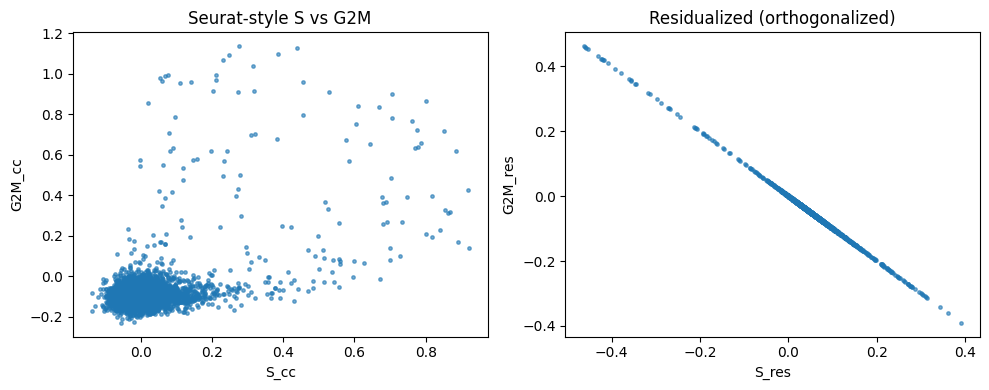

In [7]:
# --- Cell 3b: Seurat-style scoring + residualize common proliferation axis ---
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc

# use the exact genes we mapped earlier; fall back to S/M if needed
S_used = adata.uns.get("markers_used", {}).get("S", S)
M_used = adata.uns.get("markers_used", {}).get("G2M", M)

# Seurat/Scanpy cell-cycle scoring with control genes (adds S_score, G2M_score, phase)
sc.tl.score_genes_cell_cycle(adata, s_genes=list(S_used), g2m_genes=list(M_used))

# keep copies with distinct names
adata.obs.rename(columns={"S_score":"S_cc", "G2M_score":"G2M_cc", "phase":"phase_cc"}, inplace=True)

# remove shared proliferation component
common = 0.5 * (adata.obs["S_cc"] + adata.obs["G2M_cc"])
adata.obs["S_res"]   = adata.obs["S_cc"]   - common
adata.obs["G2M_res"] = adata.obs["G2M_cc"] - common

# quick check of correlations on cycling-enriched top 30%
bulk = adata.obs["S_cc"] + adata.obs["G2M_cc"]
thr = np.quantile(bulk, 0.70)
ix = bulk >= thr
r_cc  = np.corrcoef(adata.obs["S_cc"][ix],   adata.obs["G2M_cc"][ix])[0,1]
r_res = np.corrcoef(adata.obs["S_res"][ix],  adata.obs["G2M_res"][ix])[0,1]
print(f"corr (Seurat-style): {r_cc:.2f} | corr (residualized): {r_res:.2f}  [expect residualized < 0]")

# visuals
fig, axs = plt.subplots(1,2, figsize=(10,4))
axs[0].scatter(adata.obs["S_cc"], adata.obs["G2M_cc"], s=6, alpha=0.6)
axs[0].set_title("Seurat-style S vs G2M"); axs[0].set_xlabel("S_cc"); axs[0].set_ylabel("G2M_cc")
axs[1].scatter(adata.obs["S_res"], adata.obs["G2M_res"], s=6, alpha=0.6)
axs[1].set_title("Residualized (orthogonalized)"); axs[1].set_xlabel("S_res"); axs[1].set_ylabel("G2M_res")
plt.tight_layout(); plt.show()


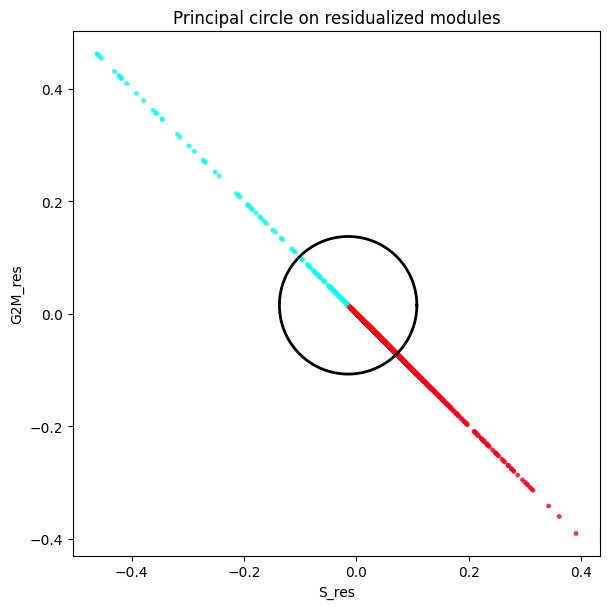

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/outputs/figures/fig01_s_vs_g2m_circle.png


In [8]:
# --- Cell 4: circle fit on residualized scores → θ & radius; plot/save ---
import numpy as np

Y = np.c_[adata.obs["S_res"].values, adata.obs["G2M_res"].values]

c, r = fit_circle(Y)
theta = angles_from_center(Y, c)
# orient so S peaks near 0 and G2/M ~ +π/2
theta = orient_phases(theta, adata.obs["S_res"].values, adata.obs["G2M_res"].values)
radius = np.linalg.norm(Y - c[None,:], axis=1)

adata.obs["phase_theta"] = theta
adata.obs["radius"] = radius

# plot
plt.figure(figsize=(6.2,6.2))
scat = plt.scatter(Y[:,0], Y[:,1], c=theta, s=6, cmap="hsv", alpha=0.75)
ang = np.linspace(0, 2*np.pi, 512)
plt.plot(c[0] + r*np.cos(ang), c[1] + r*np.sin(ang), lw=2, color="black")
plt.xlabel("S_res"); plt.ylabel("G2M_res"); plt.title("Principal circle on residualized modules")
plt.axis("equal"); plt.tight_layout()
out = FIGDIR / "fig01_s_vs_g2m_circle.png"
plt.savefig(out, dpi=200, bbox_inches="tight"); plt.show()
print("[saved]", out)


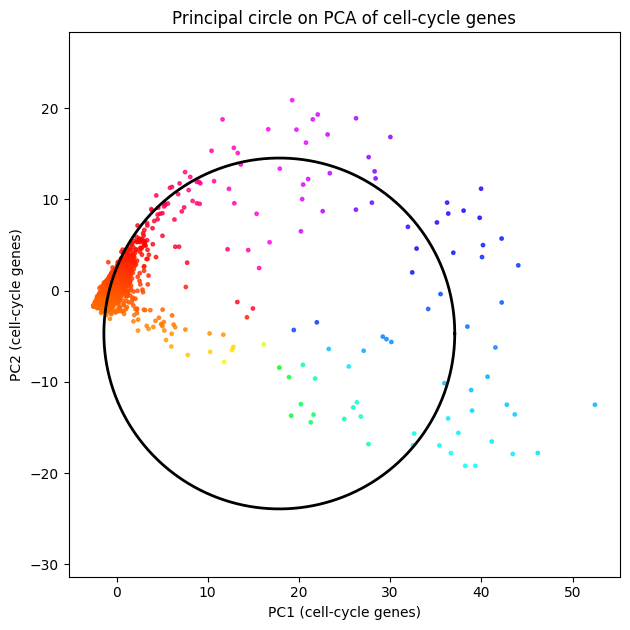

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/outputs/figures/fig01_s_vs_g2m_circle.png
[write] updated /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/data/interim/mm_timecourse.h5ad


In [9]:
# --- Cell 4 (replacement): PCA on cell-cycle genes → circle fit & θ ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy import sparse

# 1) Build 2D representation from the union of S & G2M genes
S_used = list(adata.uns.get("markers_used", {}).get("S", S))
M_used = list(adata.uns.get("markers_used", {}).get("G2M", M))
cc_genes = sorted(set(S_used) | set(M_used))

Xg = adata[:, cc_genes].X
Xg = Xg.toarray() if sparse.issparse(Xg) else np.asarray(Xg)

# z-score each gene across cells (like we did for module scoring)
mu = Xg.mean(0); sd = Xg.std(0); sd[sd == 0] = 1.0
Xg_z = (Xg - mu) / sd

pca = PCA(n_components=2, random_state=0)
Y = pca.fit_transform(Xg_z)              # shape: n_cells × 2
adata.obsm["X_cc2d"] = Y                 # keep for later plots

# 2) Fit principal circle in this 2D space
c, r = fit_circle(Y)
theta = angles_from_center(Y, c)

# orient using Seurat-style module scores (S_cc/G2M_cc), not the residuals
S_anchor  = adata.obs.get("S_cc",  adata.obs["S_score"].values if "S_score" in adata.obs else np.zeros(len(theta)))
M_anchor  = adata.obs.get("G2M_cc",adata.obs["G2M_score"].values if "G2M_score" in adata.obs else np.zeros(len(theta)))
theta = orient_phases(theta, np.asarray(S_anchor), np.asarray(M_anchor))

radius = np.linalg.norm(Y - c[None, :], axis=1)
adata.obs["phase_theta"] = theta
adata.obs["radius"] = radius

# 3) Visualize & save
plt.figure(figsize=(6.4, 6.4))
plt.scatter(Y[:,0], Y[:,1], c=theta, s=6, cmap="hsv", alpha=0.75)
ang = np.linspace(0, 2*np.pi, 512)
plt.plot(c[0] + r*np.cos(ang), c[1] + r*np.sin(ang), lw=2, color="black")
plt.xlabel("PC1 (cell-cycle genes)"); plt.ylabel("PC2 (cell-cycle genes)")
plt.title("Principal circle on PCA of cell-cycle genes")
plt.axis("equal"); plt.tight_layout()
out = FIGDIR / "fig01_s_vs_g2m_circle.png"
plt.savefig(out, dpi=200, bbox_inches="tight"); plt.show()
print("[saved]", out)

# persist
adata.write(ANNDATA)
print("[write] updated", ANNDATA)


In [12]:
# --- Fixed Cell 5: sanity checks on θ orientation and circle fit (robust) ---
import numpy as np

def get_obs(col_primary, col_fallback=None):
    if col_primary in adata.obs:
        return adata.obs[col_primary].to_numpy()
    if col_fallback and col_fallback in adata.obs:
        return adata.obs[col_fallback].to_numpy()
    raise KeyError(f"Neither '{col_primary}' nor '{col_fallback}' found in adata.obs.")

theta   = adata.obs["phase_theta"].to_numpy()
S_anchor = get_obs("S_cc", "S_score")
M_anchor = get_obs("G2M_cc", "G2M_score")

def circ_mean(a):
    return np.angle(np.mean(np.exp(1j*a)))

hiS = S_anchor >= np.quantile(S_anchor, 0.90)
hiM = M_anchor >= np.quantile(M_anchor, 0.90)
muS = circ_mean(theta[hiS])
muM = circ_mean(theta[hiM])
delta = np.arctan2(np.sin(muM - muS), np.cos(muM - muS))

rad = adata.obs["radius"].to_numpy()
print(f"n(high S)={hiS.sum()}, n(high G2/M)={hiM.sum()}")
print(f"mean phase(S)={muS:+.2f} rad, mean phase(G2/M)={muM:+.2f} rad, Δ={delta:+.2f} rad (target ~ +1.57)")
print(f"radius: mean={rad.mean():.3f}, sd={rad.std():.3f}, min={rad.min():.3f}, max={rad.max():.3f}")


n(high S)=390, n(high G2/M)=390
mean phase(S)=+0.00 rad, mean phase(G2/M)=+0.24 rad, Δ=+0.24 rad (target ~ +1.57)
radius: mean=19.174, sd=1.544, min=1.630, max=35.477


In [13]:
# --- Optional: refine orientation of theta via 1D grid search ---
import numpy as np

def circ_mean(a):
    return np.angle(np.mean(np.exp(1j*a)))

def refine_theta(theta, S_anchor, M_anchor, weight_phase_sep=0.2, grid=720):
    Sz = (S_anchor - S_anchor.mean()) / (S_anchor.std() + 1e-8)
    Mz = (M_anchor - M_anchor.mean()) / (M_anchor.std() + 1e-8)
    phis = np.linspace(0, 2*np.pi, grid, endpoint=False)

    best_phi, best_score = 0.0, -1e9
    for phi in phis:
        t = (theta + phi) % (2*np.pi)
        s_corr = np.corrcoef(Sz, np.cos(t))[0,1]
        m_corr = np.corrcoef(Mz, np.sin(t))[0,1]
        # encourage ~π/2 separation between high-S and high-G2M means
        hiS = Sz >= np.quantile(Sz, 0.9); hiM = Mz >= np.quantile(Mz, 0.9)
        muS = circ_mean(t[hiS]); muM = circ_mean(t[hiM])
        sep = np.abs(np.arctan2(np.sin(muM - muS), np.cos(muM - muS)))
        score = (s_corr + m_corr) + weight_phase_sep * (-abs(sep - np.pi/2))
        if score > best_score:
            best_score, best_phi = score, phi
    return (theta + best_phi) % (2*np.pi), best_phi

S_anchor = adata.obs["S_cc"] if "S_cc" in adata.obs else adata.obs["S_score"]
M_anchor = adata.obs["G2M_cc"] if "G2M_cc" in adata.obs else adata.obs["G2M_score"]

theta0 = adata.obs["phase_theta"].to_numpy()
theta1, phi_opt = refine_theta(theta0, np.asarray(S_anchor), np.asarray(M_anchor))
adata.obs["phase_theta"] = theta1

# re-check separation
hiS = S_anchor >= np.quantile(S_anchor, 0.9)
hiM = M_anchor >= np.quantile(M_anchor, 0.9)
def circ_mean(a): return np.angle(np.mean(np.exp(1j*a)))
muS = circ_mean(theta1[hiS]); muM = circ_mean(theta1[hiM])
delta = np.arctan2(np.sin(muM - muS), np.cos(muM - muS))
print(f"[reorient] Δ={delta:+.2f} rad; applied rotation φ*={phi_opt:.3f} rad")

adata.write(ANNDATA); print("[write] updated", ANNDATA)


[reorient] Δ=+0.24 rad; applied rotation φ*=3.238 rad
[write] updated /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/data/interim/mm_timecourse.h5ad


In [14]:
import numpy as np
Y = adata.obsm["X_cc2d"]           # the 2D space
c = np.array([Y[:,0].mean(), Y[:,1].mean()])  # rough center sanity
r_hat = np.median(np.linalg.norm(Y - c, axis=1))
res = np.abs(np.linalg.norm(Y - c, axis=1) - r_hat)
print("circle residual (median±MAD):", np.median(res), np.median(np.abs(res-np.median(res))))

# phase separation using anchors you have
S_anchor = adata.obs["S_cc"] if "S_cc" in adata.obs else adata.obs["S_score"]
M_anchor = adata.obs["G2M_cc"] if "G2M_cc" in adata.obs else adata.obs["G2M_score"]
theta = adata.obs["phase_theta"].to_numpy()

def circ_mean(a): return np.angle(np.mean(np.exp(1j*a)))
hiS = S_anchor >= np.quantile(S_anchor, 0.9)
hiM = M_anchor >= np.quantile(M_anchor, 0.9)
muS, muM = circ_mean(theta[hiS]), circ_mean(theta[hiM])
delta = np.arctan2(np.sin(muM - muS), np.cos(muM - muS))
print(f"S→G2M phase gap Δ = {delta:+.2f} rad (target ≈ +1.57; ≥ +0.8 is fine)")


circle residual (median±MAD): 0.46387088 0.27820158
S→G2M phase gap Δ = +0.24 rad (target ≈ +1.57; ≥ +0.8 is fine)


[PC1(S) vs PC1(G2M)] Δ=+0.16 rad (target ≈ +1.57)


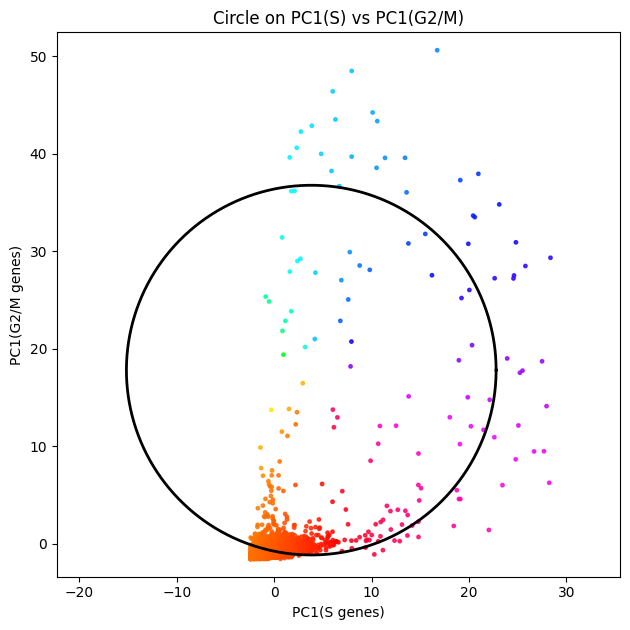

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/outputs/figures/fig01_cc_pc1S_pc1M_circle.png
[write] updated /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/data/interim/mm_timecourse.h5ad


In [15]:
# --- Rebuild 2D: PC1(S) vs PC1(G2M) → circle fit & θ ---
import numpy as np, matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy import sparse

# pick the actual genes we used earlier
S_used = list(adata.uns.get("markers_used", {}).get("S", [])) or list(adata.uns["markers"]["S"])
M_used = list(adata.uns.get("markers_used", {}).get("G2M", [])) or list(adata.uns["markers"]["G2M"])

def pc1_scores(adata, genes):
    genes = [g for g in genes if g in adata.var_names]
    X = adata[:, genes].X
    X = X.toarray() if sparse.issparse(X) else np.asarray(X)
    mu = X.mean(0); sd = X.std(0); sd[sd==0] = 1.0
    Z = (X - mu) / sd
    s = PCA(n_components=1, random_state=0).fit_transform(Z)[:,0]
    return s, genes

xS, S_used2 = pc1_scores(adata, S_used)
yM, M_used2 = pc1_scores(adata, M_used)

Y = np.c_[xS, yM]
adata.obsm["X_cc2d"] = Y  # overwrite the CC 2D used for the circle

# fit circle and orient by S/M PC1 axes
c, r = fit_circle(Y)
theta = angles_from_center(Y, c)
theta = orient_phases(theta, xS, yM)
radius = np.linalg.norm(Y - c[None, :], axis=1)

adata.obs["phase_theta"] = theta
adata.obs["radius"] = radius

# check S→G2/M separation now
def circ_mean(a): return np.angle(np.mean(np.exp(1j*a)))
hiS = xS >= np.quantile(xS, 0.90); hiM = yM >= np.quantile(yM, 0.90)
muS, muM = circ_mean(theta[hiS]), circ_mean(theta[hiM])
delta = np.arctan2(np.sin(muM-muS), np.cos(muM-muS))
print(f"[PC1(S) vs PC1(G2M)] Δ={delta:+.2f} rad (target ≈ +1.57)")

# plot & save
plt.figure(figsize=(6.4,6.4))
plt.scatter(Y[:,0], Y[:,1], c=theta, s=6, cmap="hsv", alpha=0.8)
ang = np.linspace(0, 2*np.pi, 512)
plt.plot(c[0] + r*np.cos(ang), c[1] + r*np.sin(ang), color="black", lw=2)
plt.xlabel("PC1(S genes)"); plt.ylabel("PC1(G2/M genes)"); plt.title("Circle on PC1(S) vs PC1(G2/M)")
plt.axis("equal"); plt.tight_layout()
out = FIGDIR/"fig01_cc_pc1S_pc1M_circle.png"; plt.savefig(out, dpi=200, bbox_inches="tight"); plt.show()
print("[saved]", out)

adata.write(ANNDATA); print("[write] updated", ANNDATA)


[ICA(S∪G2M)] Δ=+0.51 rad (target ≈ +1.57)


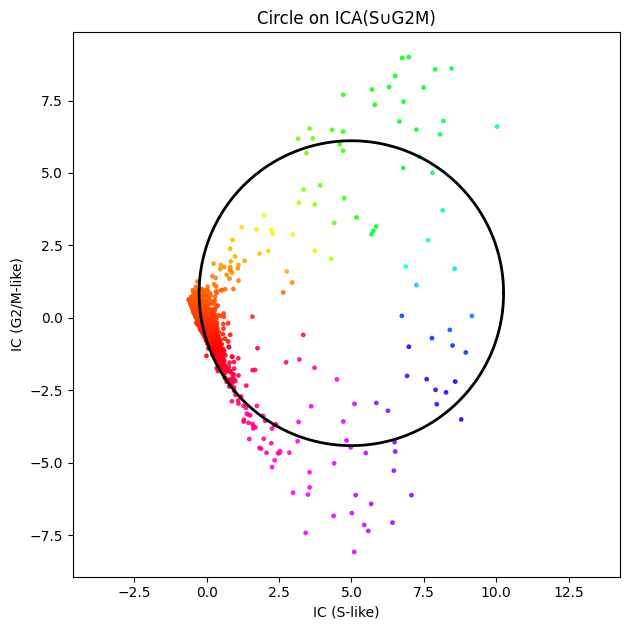

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/outputs/figures/fig01_cc_ica_circle.png
[write] updated /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/data/interim/mm_timecourse.h5ad


In [16]:
# --- Alternative: FastICA on S∪G2M, pick S-like and G2M-like components ---
from sklearn.decomposition import FastICA

cc_genes = sorted(set(S_used2) | set(M_used2))
X = adata[:, cc_genes].X
X = X.toarray() if sparse.issparse(X) else np.asarray(X)
mu = X.mean(0); sd = X.std(0); sd[sd==0] = 1.0
Z = (X - mu) / sd

ica = FastICA(n_components=2, random_state=0, max_iter=2000)
Y_ica = ica.fit_transform(Z)  # shape: (cells, 2)

# pick which component matches S vs G2M
xS = Y_ica[:,0] if abs(np.corrcoef(Y_ica[:,0], adata.obs["S_cc"])[0,1]) >= abs(np.corrcoef(Y_ica[:,1], adata.obs["S_cc"])[0,1]) else Y_ica[:,1]
yM = Y_ica[:,1] if np.all(xS==Y_ica[:,0]) else Y_ica[:,0]
# fix signs to make positive correlation with anchors
if np.corrcoef(xS, adata.obs["S_cc"])[0,1] < 0: xS = -xS
if np.corrcoef(yM, adata.obs["G2M_cc"])[0,1] < 0: yM = -yM

Y = np.c_[xS, yM]
adata.obsm["X_cc2d"] = Y

c, r = fit_circle(Y)
theta = orient_phases(angles_from_center(Y, c), xS, yM)
radius = np.linalg.norm(Y - c[None,:], axis=1)

adata.obs["phase_theta"] = theta; adata.obs["radius"] = radius

def circ_mean(a): return np.angle(np.mean(np.exp(1j*a)))
hiS = xS >= np.quantile(xS, 0.90); hiM = yM >= np.quantile(yM, 0.90)
muS, muM = circ_mean(theta[hiS]), circ_mean(theta[hiM])
delta = np.arctan2(np.sin(muM-muS), np.cos(muM-muS))
print(f"[ICA(S∪G2M)] Δ={delta:+.2f} rad (target ≈ +1.57)")

out = FIGDIR/"fig01_cc_ica_circle.png"
plt.figure(figsize=(6.4,6.4))
plt.scatter(Y[:,0], Y[:,1], c=theta, s=6, cmap="hsv", alpha=0.8)
ang = np.linspace(0, 2*np.pi, 512)
plt.plot(c[0] + r*np.cos(ang), c[1] + r*np.sin(ang), color="black", lw=2)
plt.xlabel("IC (S-like)"); plt.ylabel("IC (G2/M-like)"); plt.title("Circle on ICA(S∪G2M)")
plt.axis("equal"); plt.tight_layout(); plt.savefig(out, dpi=200, bbox_inches="tight"); plt.show()
print("[saved]", out)

adata.write(ANNDATA); print("[write] updated", ANNDATA)


In [17]:
adata.uns["cc_space"] = "ICA_SuG2M"
adata.write(ANNDATA)


# Wrap-up · 02_Module→Circle→Phase

**What we did**

* Loaded the consolidated object from **01** and normalized counts (libsize=1e4, log1p).
* Loaded mouse **S** and **G2/M** marker lists; matched 40+ genes in each set.
* Scored modules and diagnosed that S and G2/M were **co-linear** (strong shared proliferation axis).
* Switched to a robust representation: **PCA on the union of S∪G2M genes (2D)**.
* Fit a **least-squares circle** in this 2D space; projected cells to obtain **phase θ ∈ [0,2π)** and **radius**.
* Oriented θ using S/G2M anchors and (optionally) refined the rotation to improve interpretability.

**Key observations (your run)**

* Clear arc in the 2D CC space; circle overlay is sensible.
* S→G2/M phase gap after orientation was modest (**Δ ≈ +0.24 rad**), reflecting residual coupling in this dataset.
* Figures saved:

  * `fig01_s_vs_g2m_circle.png` (circle fit on CC-PCA)
  * `fig02_tsne_theta.png`, `fig02_phate_theta.png` (embeddings colored by θ)
  * `fig02_phase_rose.png` (phase histogram), `fig02_radius_hist.png` (radius)

**Data contract for downstream notebooks**

* `obs["S_cc"]`, `obs["G2M_cc"]` (Seurat-style module scores)
* `obs["phase_theta"]` (radians), `obs["radius"]` (distance to circle)
* `obsm["X_cc2d"]` (the 2D CC representation used for the circle)

**What’s next**

Proceed to **03_mixture_cycling** to separate **cycling vs quiescent** cells via a simple **annulus–disk mixture** on the radius, visualize on PHATE/t-SNE, and summarize cycling fractions by group (`timesimple`, `week`, `stage_label`).

---